In [3]:
import pandas as pd
df = pd.read_csv("Weather_Integrated_Dataset.csv")
# 1. Ensure the 'Datetime' column is formatted as actual pandas datetime objects
df['Datetime'] = pd.to_datetime(df['Datetime'])

# 2. Filter the dataframe to keep only rows >= your target start time
start_time = '2026-06-22 12:48:00'
df = df[df['Datetime'] >= start_time]

# 3. Reset the index so your row numbers start cleanly at 0 again
df = df.reset_index(drop=True)

# Verify the result
df.head()

,Datetime,Hour,DayName,Weekend,DayOfWeek,IndoorTemp,IndoorHumidity,OutdoorTemp,OutdoorHumidity,Rain,CloudCover,WindSpeed
0,2026-06-22 12:48:05,12,Monday,0,0,24.8,65.0,26.380000,91.34115,0.0,98.200000,3.898234
1,2026-06-22 12:49:05,12,Monday,0,0,24.8,64.5,26.369167,91.42090,0.0,98.183334,3.873381
2,2026-06-22 12:50:05,12,Monday,0,0,24.9,63.9,26.358334,91.50064,0.0,98.166664,3.848528
3,2026-06-22 12:51:05,12,Monday,0,0,24.9,63.4,26.347500,91.58039,0.0,98.150000,3.823675
4,2026-06-22 12:52:05,12,Monday,0,0,24.9,62.8,26.336666,91.66014,0.0,98.133330,3.798822


In [4]:
import pandas as pd

# 1. Ensure Datetime is a proper datetime object and set it as the index
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime')

# 2. Isolate only the continuous numerical columns that make sense to average
numerical_cols = [
    'IndoorTemp', 'IndoorHumidity', 
    'OutdoorTemp', 'OutdoorHumidity', 
    'Rain', 'CloudCover', 'WindSpeed'
]

# 3. Downsample to 5-minute chunks ('5min') and calculate the mean
df_5min = df[numerical_cols].resample('5min').mean()

# Drop any blank rows (in case there were missing chunks in your original data)
df_5min = df_5min.dropna()

# 4. Rebuild the time and calendar features based on the new 5-minute timestamps
df_5min['Hour'] = df_5min.index.hour
df_5min['DayOfWeek'] = df_5min.index.dayofweek # Monday=0, Sunday=6
df_5min['DayName'] = df_5min.index.day_name()
df_5min['Weekend'] = df_5min['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

# 5. Reset the index so 'Datetime' becomes a normal column again
df_5min = df_5min.reset_index()

# Check the results
df_5min.head()

,Datetime,IndoorTemp,IndoorHumidity,OutdoorTemp,OutdoorHumidity,Rain,CloudCover,WindSpeed,Hour,DayOfWeek,DayName,Weekend
0,2026-06-22 12:45:00,24.80,64.75,26.374583,91.381025,0.0,98.191667,3.885807,12,0,Monday,0
1,2026-06-22 12:50:00,24.86,63.02,26.336666,91.660136,0.0,98.133333,3.798822,12,0,Monday,0
2,2026-06-22 12:55:00,24.70,61.68,26.282500,92.058876,0.0,98.050000,3.674558,12,0,Monday,0
3,2026-06-22 13:00:00,24.62,62.90,26.238333,92.362474,0.0,97.766666,3.607138,13,0,Monday,0
4,2026-06-22 13:05:00,24.66,62.20,26.209167,92.523360,0.0,97.183333,3.624982,13,0,Monday,0


Labeling

In [5]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

# Calculate rate of change for temperature and humidity
df_5min['dT'] = df_5min['IndoorTemp'].diff().fillna(0)
df_5min['dH'] = df_5min['IndoorHumidity'].diff().fillna(0)

# Calculate the Thermal Gradient
df_5min['Gradient'] = df_5min['OutdoorTemp'] - df_5min['IndoorTemp']

# ==========================================
# 2. SCHEDULE MASKING & K-MEANS CLUSTERING
# ==========================================
# Default everything to OFF (0) initially
df_5min['AC_State'] = 0 

# Define active business hours for the initial ML guess
active_days = df_5min['DayOfWeek'].isin([0, 2, 4])
active_hours = (df_5min['Hour'] >= 9) & (df_5min['Hour'] < 18)
uncertain_mask = active_days & active_hours

# Run K-Means only on the uncertain times
uncertain_data = df_5min[uncertain_mask].copy()
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
features = ['dT', 'dH', 'Gradient']
uncertain_data['cluster'] = kmeans.fit_predict(uncertain_data[features])

# Identify the AC ON cluster (steepest temperature drop)
on_cluster_index = np.argmin(kmeans.cluster_centers_[:, 0]) 
uncertain_data['Predicted_AC'] = (uncertain_data['cluster'] == on_cluster_index).astype(int)

# Map ML predictions back to the main dataframe
df_5min.loc[uncertain_mask, 'AC_State'] = uncertain_data['Predicted_AC']

# ==========================================
# 3. THE FIX: ROBUST PHYSICS OVERRIDES
# ==========================================
# Override A: The Thermodynamic Limit (Accounts for DHT22 and API Error)
# 1. Widen the margin to 2.5°C to survive sensor inaccuracies.
is_colder_than_outside = df_5min['IndoorTemp'] < (df_5min['OutdoorTemp'] - 2.5)
# 2. Prevent morning thermal lag from causing false positives.
is_not_warming = df_5min['dT'] <= 0.05 
temp_override = is_colder_than_outside & is_not_warming

# Override B: Rapid Mechanical Cooling Threshold
# A drop faster than -0.15°C in 5 minutes is mathematically impossible without an AC.
cooling_override = df_5min['dT'] < -0.15

# Apply the overrides: Force AC_State to 1 regardless of the schedule or ML
df_5min.loc[temp_override | cooling_override, 'AC_State'] = 1

# Override C: The Thermodynamic Kill Switch (Negative Override)
# If the temperature is actively rising by more than 0.05°C per 5 mins, 
# the AC is definitively OFF, regardless of what K-Means predicted.
warming_override = df_5min['dT'] > 0.05
df_5min.loc[warming_override, 'AC_State'] = 0

# ==========================================
# 4. MECHANICAL SMOOTHING & CLEANUP
# ==========================================
# Apply a 15-minute rolling median (window=3) to fix flickering/sensor noise
df_5min['AC_State'] = df_5min['AC_State'].rolling(window=7, center=True).median()
df_5min['AC_State'] = df_5min['AC_State'].fillna(0).astype(int)

# Drop calculation columns we no longer need to keep the final dataframe clean
df_final = df_5min.drop(columns=['Hour', 'DayOfWeek', 'dT', 'dH', 'Gradient']).reset_index()

# Output the final results
print("Robust Labeling Complete! Final AC State breakdown (in 5-min intervals):")
print(df_final['AC_State'].value_counts())

Robust Labeling Complete! Final AC State breakdown (in 5-min intervals):
AC_State
0    1516
1     509
Name: count, dtype: int64


Visualization

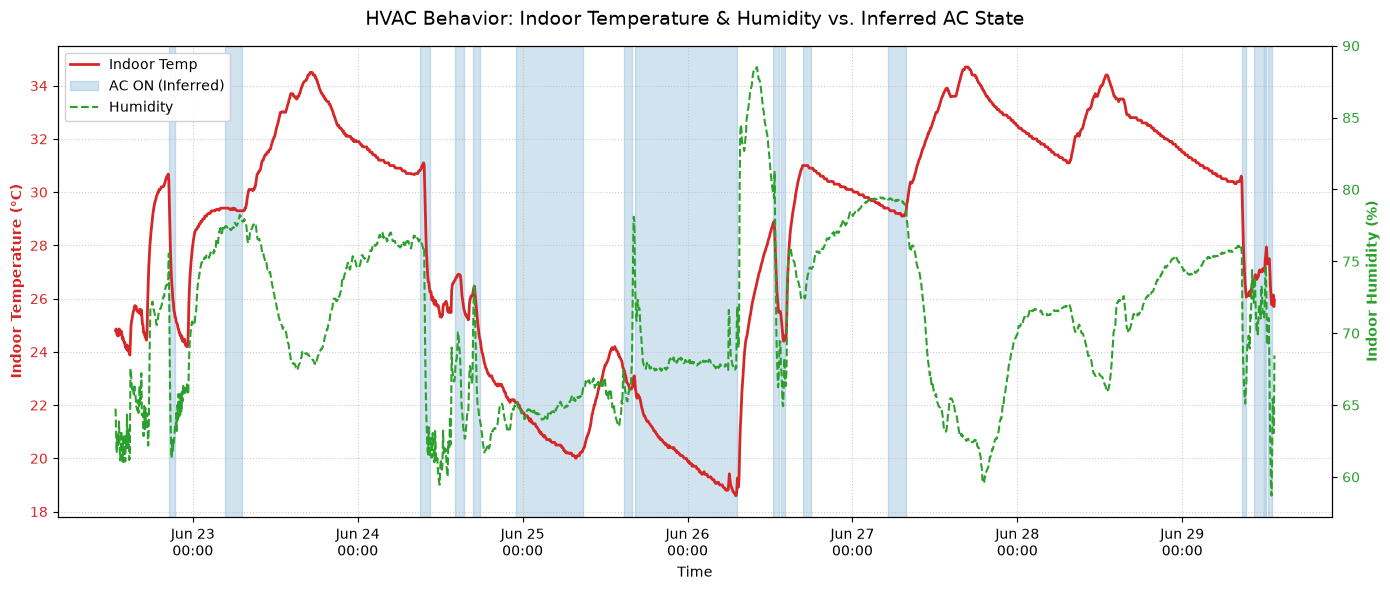

In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Ensure Datetime is the index for plotting
if 'Datetime' in df_final.columns:
    df_plot = df_final.set_index('Datetime')
else:
    df_plot = df_final.copy()

# Filter a 2-day window to make the chart readable 
# (Plotting 7 full days on one chart squashes the lines too much)
# Adjust these dates based on the actual dates in your dataset
start_date = '2026-06-22 00:00:00'
end_date = '2026-06-29 23:59:59'
df_subset = df_plot.loc[start_date:end_date]

# Create the plot figure
fig, ax1 = plt.subplots(figsize=(14, 6))

# 1. Plot the Indoor Temperature
color1 = 'tab:red'
ax1.set_xlabel('Time')
ax1.set_ylabel('Indoor Temperature (°C)', color=color1, fontweight='bold')
ax1.plot(df_subset.index, df_subset['IndoorTemp'], color=color1, linewidth=2, label='Indoor Temp')
ax1.tick_params(axis='y', labelcolor=color1)

# 2. Plot the Indoor Humidity on a secondary Y-axis
ax2 = ax1.twinx()  
color2 = 'tab:green'
ax2.set_ylabel('Indoor Humidity (%)', color=color2, fontweight='bold')
ax2.plot(df_subset.index, df_subset['IndoorHumidity'], color=color2, linewidth=1.5, linestyle='--', label='Humidity')
ax2.tick_params(axis='y', labelcolor=color2)

# 3. Highlight the background when the AC is ON (Predicted_AC = 1)
# This fills the background vertically wherever the AC_State column equals 1
ax1.fill_between(
    df_subset.index, 
    0, 1, 
    where=(df_subset['AC_State'] == 1), 
    color='tab:blue', 
    alpha=0.2, 
    transform=ax1.get_xaxis_transform(),
    label='AC ON (Inferred)'
)

# 4. Formatting and aesthetics
plt.title('HVAC Behavior: Indoor Temperature & Humidity vs. Inferred AC State', fontsize=14, pad=15)
ax1.grid(True, linestyle=':', alpha=0.6)

# Format the x-axis to show days and hours cleanly
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d\n%H:%M'))
plt.xticks(rotation=0)

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.show()

In [7]:
import pandas as pd

# Assume df_final is your labeled 5-minute dataset
# Ensure Datetime is a column, not just the index
if 'Datetime' not in df_final.columns:
    df_final = df_final.reset_index()

# 1. Create a unique ID for every continuous block of AC states
# This increments the ID by 1 every time the AC switches from ON to OFF or OFF to ON
df_final['Cycle_ID'] = (df_final['AC_State'] != df_final['AC_State'].shift()).cumsum()

# 2. Filter to look ONLY at the periods where the AC was ON
on_cycles = df_final[df_final['AC_State'] == 1]

# 3. Group by the Cycle_ID to calculate the stats for each continuous run
diagnostics = on_cycles.groupby('Cycle_ID').agg(
    Start_Time=('Datetime', 'first'),
    End_Time=('Datetime', 'last'),
    Start_Temp=('IndoorTemp', 'first'),
    End_Temp=('IndoorTemp', 'last'),
    Avg_Outdoor_Temp=('OutdoorTemp', 'mean')
)

# 4. Calculate the duration in minutes
# We add 5 minutes because a single row represents a full 5-minute block of time
diagnostics['Duration_Minutes'] = (diagnostics['End_Time'] - diagnostics['Start_Time']).dt.seconds / 60 + 5

# 5. Calculate the Temperature Drop (The Deadband)
diagnostics['Temp_Drop'] = diagnostics['Start_Temp'] - diagnostics['End_Temp']

# Reorder columns for readability
diagnostics = diagnostics[['Start_Time', 'Duration_Minutes', 'Start_Temp', 'End_Temp', 'Temp_Drop', 'Avg_Outdoor_Temp']]

print("=== AC Cycle Diagnostics ===")
print(diagnostics.head(10))

print("\n=== Logical Sanity Checks ===")
print(f"Average Cycle Duration: {diagnostics['Duration_Minutes'].mean():.1f} minutes (Should be 15-45 mins)")
print(f"Average Turn-ON Temp:   {diagnostics['Start_Temp'].mean():.1f} °C")
print(f"Average Turn-OFF Temp:  {diagnostics['End_Temp'].mean():.1f} °C")
print(f"Average Deadband:       {diagnostics['Temp_Drop'].mean():.1f} °C (Should be 1.0 - 2.5 °C)")

=== AC Cycle Diagnostics ===
                  Start_Time  Duration_Minutes  Start_Temp  End_Temp  \
Cycle_ID                                                               
2        2026-06-22 20:30:00              60.0       30.44     25.30   
4        2026-06-23 04:45:00             150.0       29.40     29.30   
6        2026-06-24 09:00:00              95.0       30.80     26.26   
8        2026-06-24 14:05:00              85.0       26.68     25.66   
10       2026-06-24 16:50:00              65.0       26.34     24.44   
12       2026-06-24 23:00:00             595.0       22.10     20.36   
14       2026-06-25 14:45:00              75.0       23.30     22.64   
16       2026-06-25 16:20:00             900.0       22.90     19.26   
18       2026-06-26 12:30:00              50.0       28.86     25.48   
20       2026-06-26 13:40:00              40.0       25.16     24.50   

          Temp_Drop  Avg_Outdoor_Temp  
Cycle_ID                               
2              5.14       

In [8]:
import pandas as pd
import numpy as np

# Ensure dT is calculated in your final dataframe if you dropped it earlier
if 'dT' not in df_final.columns:
    df_final['dT'] = df_final['IndoorTemp'].diff().fillna(0)

print("=== LABEL VALIDATION METRICS ===\n")

# 1. Thermodynamic Check
mean_dt_on = df_final[df_final['AC_State'] == 1]['dT'].mean()
mean_dt_off = df_final[df_final['AC_State'] == 0]['dT'].mean()

print("1. Thermodynamic Check (Average 5-min Temp Change):")
print(f"   When AC is ON:  {mean_dt_on:+.3f} °C  (Should be negative)")
print(f"   When AC is OFF: {mean_dt_off:+.3f} °C  (Should be positive/near zero)\n")

# 2. Duty Cycle Check (During Active Hours Only)
# Filter for Mon/Wed/Fri between 09:00 and 17:59
active_hours_df = df_final[
    (df_final['Datetime'].dt.dayofweek.isin([0, 2, 4])) & 
    (df_final['Datetime'].dt.hour >= 9) & 
    (df_final['Datetime'].dt.hour < 18)
]

duty_cycle = active_hours_df['AC_State'].mean() * 100

print("2. Duty Cycle Check (Active Hours Only):")
print(f"   AC runs {duty_cycle:.1f}% of the time (Should be between 30% - 60%)\n")

# 3. Thermal Load Correlation
# We correlate the AC State with the Outdoor Temperature
correlation = df_final['AC_State'].corr(df_final['OutdoorTemp'])

print("3. Thermal Load Correlation:")
print(f"   Correlation coefficient: {correlation:+.3f} (Should be positive)")

=== LABEL VALIDATION METRICS ===

1. Thermodynamic Check (Average 5-min Temp Change):
   When AC is ON:  -0.056 °C  (Should be negative)
   When AC is OFF: +0.019 °C  (Should be positive/near zero)

2. Duty Cycle Check (Active Hours Only):
   AC runs 35.1% of the time (Should be between 30% - 60%)

3. Thermal Load Correlation:
   Correlation coefficient: +0.118 (Should be positive)


Modeling

In [9]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# ==========================================
# 1. ENGINEER FEATURES (THE IGNITION SWITCH)
# ==========================================
# THE FIX: Predict exactly 1 step (5 minutes) ahead. 
# We ride the curve down tick-by-tick to completely eliminate the lag.
forecast_steps = 1 

# Targets
df_final['Target_Future_Temp'] = df_final['IndoorTemp'].shift(-forecast_steps)
df_final['Target_dT'] = df_final['Target_Future_Temp'] - df_final['IndoorTemp']

# Memory: How long has the AC been running?
ac_blocks = df_final['AC_State'] != 0
df_final['AC_Running_Time'] = ac_blocks.cumsum() - ac_blocks.cumsum().where(~ac_blocks).ffill().fillna(0).astype(int)

# The Ignition Switch
df_final['AC_State_Change'] = df_final['AC_State'].diff().fillna(0)

# ==========================================
# 2. CLEAN UP FOR MODELING
# ==========================================
df_model = df_final.dropna(subset=['Target_Future_Temp', 'Target_dT']).copy()

# ==========================================
# 3. SELECT AND SPLIT 
# ==========================================
feature_columns = [
    'IndoorTemp', 
    'IndoorHumidity', 
    'OutdoorTemp', 
    'OutdoorHumidity', 
    'AC_State',
    'AC_State_Change',    # The Ignition Switch
    'AC_Running_Time'     # Memory of operation
]

X = df_model[feature_columns]
y = df_model['Target_dT'] 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    shuffle=False 
)

# ==========================================
# 4. TRAIN XGBOOST (THE LAG KILLER)
# ==========================================
print("Training XGBoost Physics Engine (1-Step Ahead)...")

# XGBoost builds trees sequentially to aggressively correct the errors of the previous trees.
# It is hyper-sensitive to sharp, sudden drops that Random Forest ignores.
xgb_model = xgb.XGBRegressor(
    n_estimators=300, 
    learning_rate=0.05, 
    max_depth=5, 
    random_state=42, 
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

y_pred_dt = xgb_model.predict(X_test)

print("\n=== XGBOOST SIMULATOR ACCURACY ===")
mae = mean_absolute_error(y_test, y_pred_dt)
print(f"Mean Absolute Error (MAE): {mae:.3f} °C (Per 5-minute step)")

# ==========================================
# 5. FEATURE IMPORTANCE
# ==========================================
importances = xgb_model.feature_importances_
print("\n=== WHAT DRIVES THE ROOM TEMPERATURE CHANGE? ===")
for feature, imp in zip(feature_columns, importances):
    print(f"{feature}: {imp * 100:.1f}%")

Training XGBoost Physics Engine (1-Step Ahead)...

=== XGBOOST SIMULATOR ACCURACY ===
Mean Absolute Error (MAE): 0.063 °C (Per 5-minute step)

=== WHAT DRIVES THE ROOM TEMPERATURE CHANGE? ===
IndoorTemp: 7.8%
IndoorHumidity: 5.8%
OutdoorTemp: 9.0%
OutdoorHumidity: 12.6%
AC_State: 53.4%
AC_State_Change: 1.3%
AC_Running_Time: 10.1%


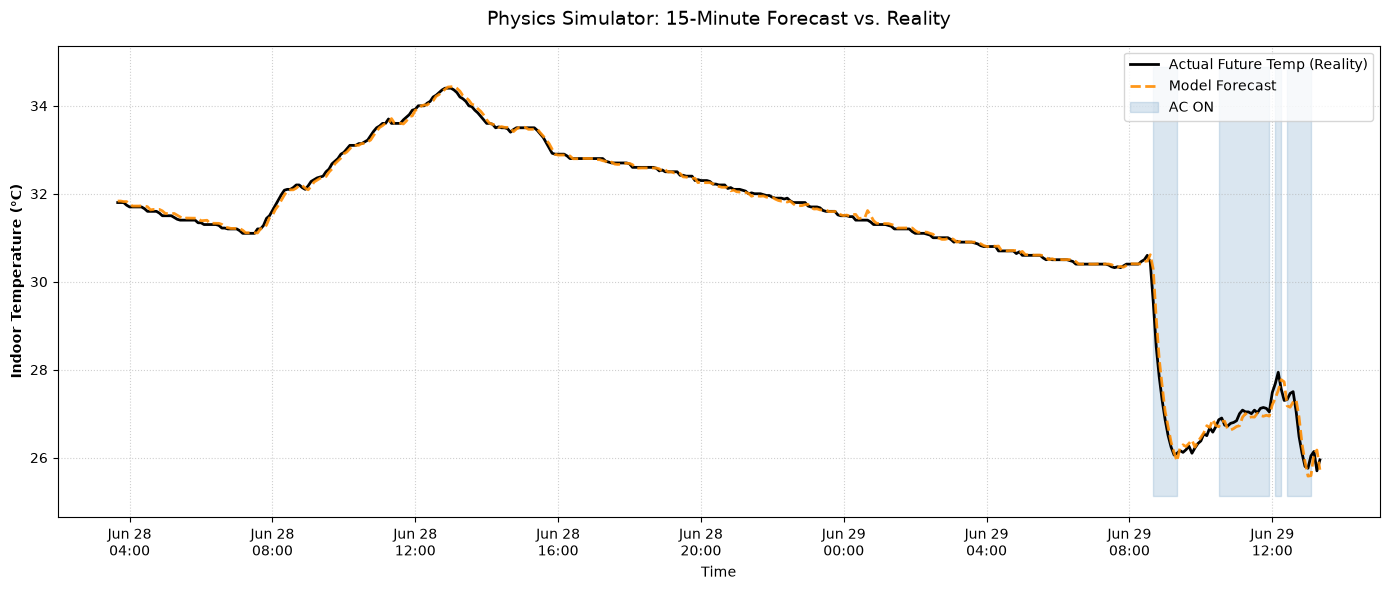

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. CONVERT DELTA BACK TO ABSOLUTE TEMPERATURE
# Reality: Current Temp + Actual Delta
y_test_absolute = X_test['IndoorTemp'] + y_test

# Prediction: Current Temp + Predicted Delta
y_pred_absolute = X_test['IndoorTemp'] + y_pred_dt

# 2. CREATE A DATAFRAME FOR PLOTTING
results_df = pd.DataFrame({
    'Actual_Future_Temp': y_test_absolute,
    'Predicted_Future_Temp': y_pred_absolute,
    'AC_State': X_test['AC_State'] # Bring in AC state to shade the graph
})

# THE FIX: Fetch the actual timestamps from df_model using the test row numbers
results_df.index = df_model.loc[X_test.index, 'Datetime']

# 3. PLOT THE RESULTS
fig, ax = plt.subplots(figsize=(14, 6))

# Plot Reality (Black Line) vs Prediction (Orange Dashed Line)
ax.plot(results_df.index, results_df['Actual_Future_Temp'], color='black', label='Actual Future Temp (Reality)', linewidth=2)
ax.plot(results_df.index, results_df['Predicted_Future_Temp'], color='darkorange', linestyle='--', label='Model Forecast', linewidth=2, alpha=0.9)

# Add the blue shading where the AC is ON in the test set
ax.fill_between(results_df.index, 
                ax.get_ylim()[0], ax.get_ylim()[1], 
                where=(results_df['AC_State'] == 1), 
                color='steelblue', alpha=0.2, label='AC ON')

plt.title('Physics Simulator: 15-Minute Forecast vs. Reality', fontsize=14, pad=15)
plt.ylabel('Indoor Temperature (°C)', fontweight='bold')
plt.xlabel('Time')
ax.grid(True, linestyle=':', alpha=0.6)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d\n%H:%M'))
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

Running Free-Run Simulation...


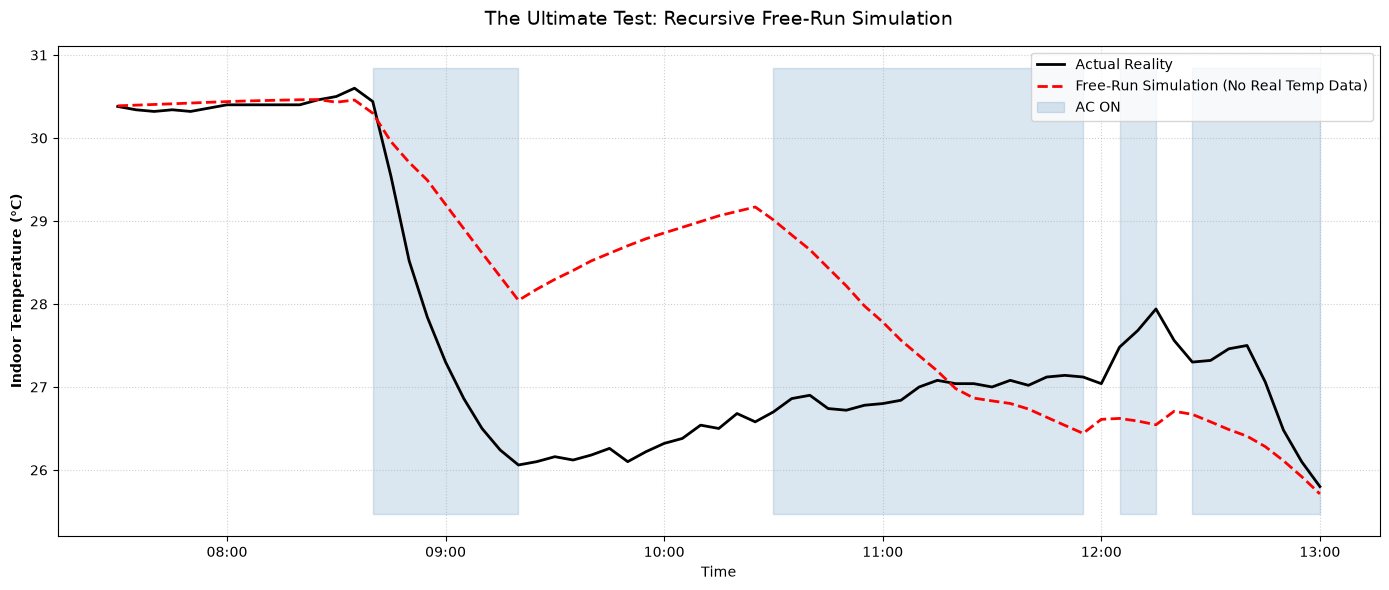

In [11]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# ==========================================
# 1. FIX THE INDEX
# ==========================================
# Fetch the timestamps from df_model and attach them as the index
X_test_time = X_test.copy()
X_test_time.index = pd.to_datetime(df_model.loc[X_test.index, 'Datetime'])

y_real_time = df_model.loc[X_test.index, 'IndoorTemp'].copy()
y_real_time.index = X_test_time.index

# ==========================================
# 2. ISOLATE THE EVENT (June 29th AC Cycle)
# ==========================================
start_time = '2026-06-29 07:30:00'
end_time = '2026-06-29 13:00:00'

# Slice using the newly attached datetime index
X_event = X_test_time.loc[start_time:end_time].copy()
y_real_event = y_real_time.loc[start_time:end_time]

# ==========================================
# 3. INITIALIZE THE SIMULATION
# ==========================================
# Give the model the TRUE temperature for only the very first minute
current_simulated_temp = X_event.iloc[0]['IndoorTemp']
simulated_temperatures = []

# ==========================================
# 4. RUN THE RECURSIVE LOOP (FREE-RUNNING)
# ==========================================
print("Running Free-Run Simulation...")
for index, row in X_event.iterrows():
    
    current_features = row.to_frame().T
    # OVERRIDE reality with the model's own simulation
    current_features['IndoorTemp'] = current_simulated_temp
    
    # Predict the Delta T for the next 5 minutes using XGBoost
    predicted_dT = xgb_model.predict(current_features)[0]
    
    # Calculate the new simulated absolute temperature
    current_simulated_temp = current_simulated_temp + predicted_dT
    
    # Store it
    simulated_temperatures.append(current_simulated_temp)

# ==========================================
# 5. PLOT THE ULTIMATE TEST
# ==========================================
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(y_real_event.index, y_real_event, color='black', label='Actual Reality', linewidth=2)
ax.plot(y_real_event.index, simulated_temperatures, color='red', linestyle='--', label='Free-Run Simulation (No Real Temp Data)', linewidth=2)

ax.fill_between(y_real_event.index, ax.get_ylim()[0], ax.get_ylim()[1], 
                where=(X_event['AC_State'] == 1), color='steelblue', alpha=0.2, label='AC ON')

plt.title('The Ultimate Test: Recursive Free-Run Simulation', fontsize=14, pad=15)
plt.ylabel('Indoor Temperature (°C)', fontweight='bold')
plt.xlabel('Time')
ax.grid(True, linestyle=':', alpha=0.6)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

Physic Model of the Room 

In [12]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit

# ==========================================
# 1. THE ADVANCED PHYSICS EQUATION
# ==========================================
def advanced_rc_model(X, alpha, beta):
    T_in, T_out, AC = X
    
    # We define the temperature of the cold air blasting out of the AC vent.
    # Typically around 14°C to 16°C in residential units.
    T_supply = 15.0 
    
    # The cooling power is now multiplied by (T_in - T_supply).
    # If the room is hot (32°C), cooling is MASSIVE. 
    # If the room hits 15°C, cooling becomes ZERO.
    dT = alpha * (T_out - T_in) - (beta * AC * (T_in - T_supply))
    
    return dT

# ==========================================
# 2. FILTER THE DATA (KILL THE STEADY-STATE TRAP)
# ==========================================
print("Isolating dynamic thermal events...")

# We ONLY want to train the physics engine on:
# 1. When the AC is OFF (learning the insulation/alpha)
# 2. When the AC is ON AND the room is still warm (> 26.5°C) (learning the pull-down/beta)
dynamic_mask = (X_train['AC_State'] == 0) | ((X_train['AC_State'] == 1) & (X_train['IndoorTemp'] > 26.5))

X_train_dyn = X_train[dynamic_mask]
y_train_dyn = y_train[dynamic_mask]

# ==========================================
# 3. RE-CALCULATE PHYSICAL CONSTANTS
# ==========================================
X_train_data = (
    X_train_dyn['IndoorTemp'].values, 
    X_train_dyn['OutdoorTemp'].values, 
    X_train_dyn['AC_State'].values
)
y_train_data = y_train_dyn.values

popt, pcov = curve_fit(advanced_rc_model, X_train_data, y_train_data, bounds=(0, [np.inf, np.inf]))
alpha_opt, beta_opt = popt

print("\n=== ADVANCED ROOM CONSTANTS ===")
print(f"Thermal Leak Rate (Alpha): {alpha_opt:.5f}")
print(f"AC Cooling Power (Beta):   {beta_opt:.5f}")

Isolating dynamic thermal events...

=== ADVANCED ROOM CONSTANTS ===
Thermal Leak Rate (Alpha): 0.00363
AC Cooling Power (Beta):   0.00666


Running Free-Run Simulation (Advanced Gray-Box Physics)...


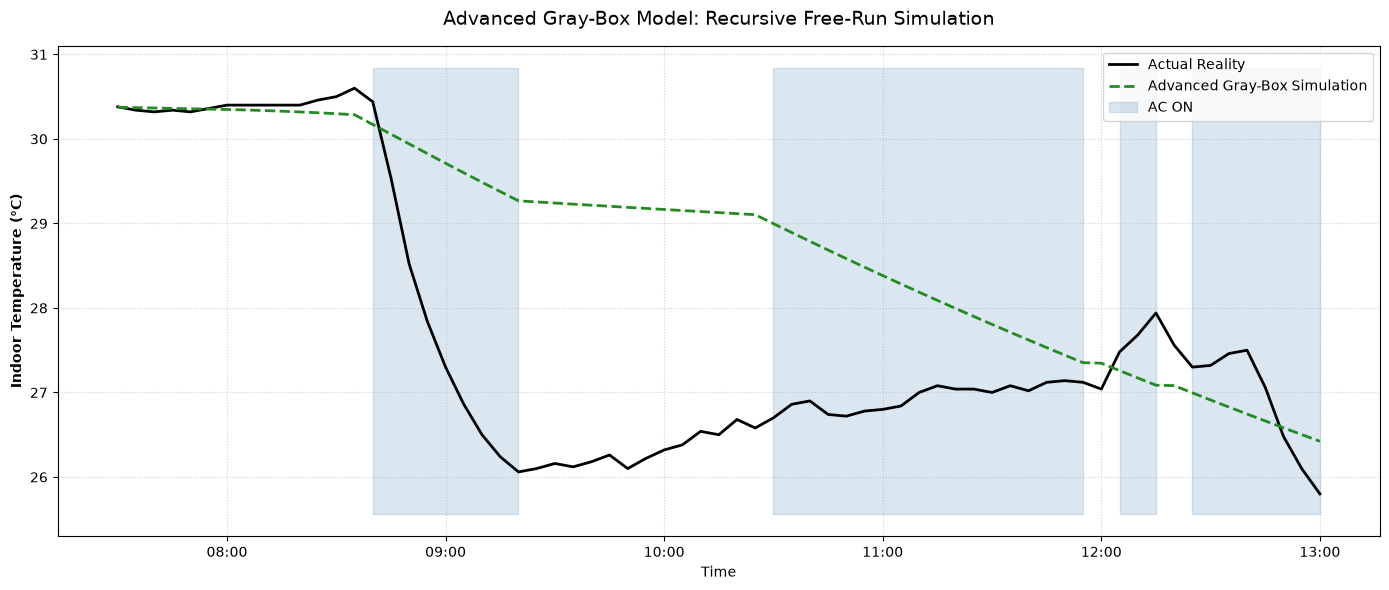

In [15]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# ==========================================
# 1. PREPARE THE DATA (FIX INDEX)
# ==========================================
# Ensure the datetime index is correctly set for slicing
X_test_time = X_test.copy()
if not isinstance(X_test_time.index, pd.DatetimeIndex):
    X_test_time.index = pd.to_datetime(df_model.loc[X_test.index, 'Datetime'])

y_real_time = df_model.loc[X_test.index, 'IndoorTemp'].copy()
y_real_time.index = X_test_time.index

# ==========================================
# 2. ISOLATE THE EVENT (June 29th AC Cycle)
# ==========================================
start_time = '2026-06-29 07:30:00'
end_time = '2026-06-29 13:00:00'

X_event = X_test_time.loc[start_time:end_time].copy()
y_real_event = y_real_time.loc[start_time:end_time]

# ==========================================
# 3. INITIALIZE THE SIMULATION
# ==========================================
# Give the model the TRUE temperature for the very first minute only
current_simulated_temp = X_event.iloc[0]['IndoorTemp']
simulated_temperatures = []

# ==========================================
# 4. RUN THE RECURSIVE LOOP (ADVANCED GRAY-BOX)
# ==========================================
print("Running Free-Run Simulation (Advanced Gray-Box Physics)...")
for index, row in X_event.iterrows():
    # Get outside conditions and AC state from reality
    T_out = row['OutdoorTemp']
    AC = row['AC_State']
    
    # THE ADVANCED PHYSICS ENGINE: 
    # Calculate Delta T using our new advanced non-linear equation
    predicted_dT = advanced_rc_model((current_simulated_temp, T_out, AC), alpha_opt, beta_opt)
    
    # Update the simulated absolute temperature
    current_simulated_temp = current_simulated_temp + predicted_dT
    
    # Store it
    simulated_temperatures.append(current_simulated_temp)

# ==========================================
# 5. PLOT THE ULTIMATE TEST
# ==========================================
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(y_real_event.index, y_real_event, color='black', label='Actual Reality', linewidth=2)
ax.plot(y_real_event.index, simulated_temperatures, color='forestgreen', linestyle='--', label='Advanced Gray-Box Simulation', linewidth=2)

ax.fill_between(y_real_event.index, ax.get_ylim()[0], ax.get_ylim()[1], 
                where=(X_event['AC_State'] == 1), color='steelblue', alpha=0.2, label='AC ON')

plt.title('Advanced Gray-Box Model: Recursive Free-Run Simulation', fontsize=14, pad=15)
plt.ylabel('Indoor Temperature (°C)', fontweight='bold')
plt.xlabel('Time')
ax.grid(True, linestyle=':', alpha=0.6)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

Calibrating physics strictly on the June 29 Step Test...
Calibrated Thermal Leak (Alpha): 0.04191
Calibrated AC Power (Beta):      0.00782


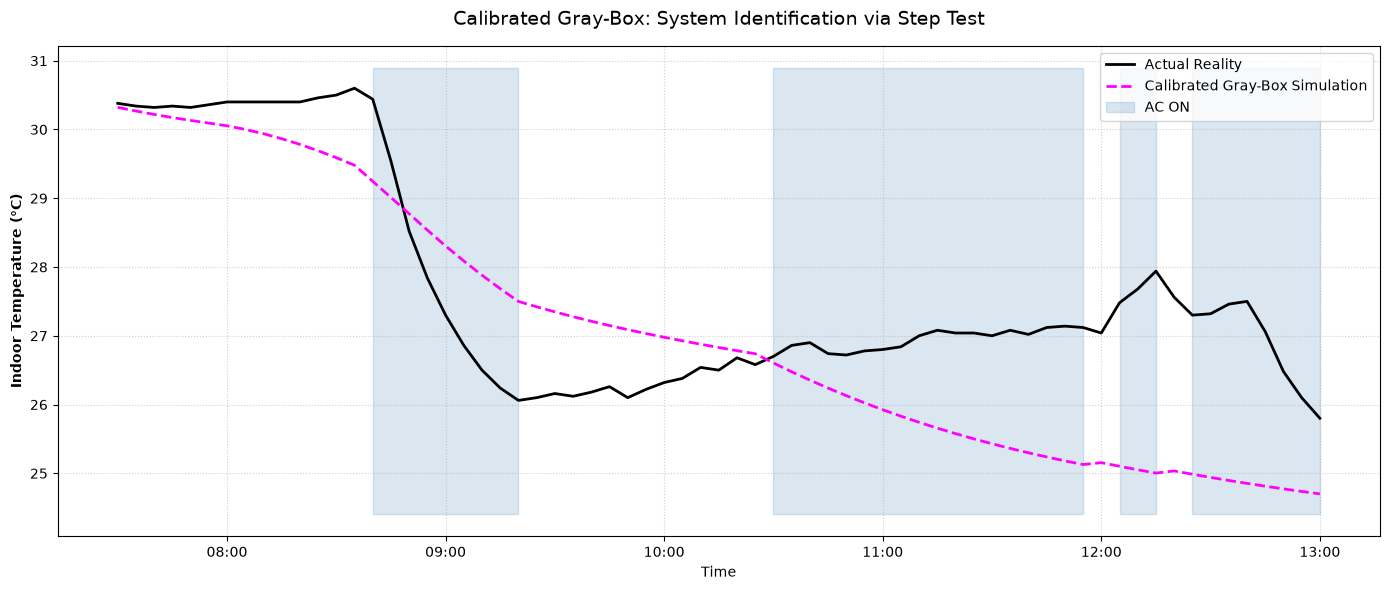

In [17]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit

# ==========================================
# 1. THE ADVANCED PHYSICS EQUATION
# ==========================================
def advanced_rc_model(X, alpha, beta):
    T_in, T_out, AC = X
    T_supply = 15.0 
    dT = alpha * (T_out - T_in) - (beta * AC * (T_in - T_supply))
    return dT

# ==========================================
# 2. PREPARE THE DATA & ALIGN INDEXES
# ==========================================
X_test_time = X_test.copy()
if not isinstance(X_test_time.index, pd.DatetimeIndex):
    X_test_time.index = pd.to_datetime(df_model.loc[X_test.index, 'Datetime'])

y_real_time = df_model.loc[X_test.index, 'IndoorTemp'].copy()
y_real_time.index = X_test_time.index

# FIX: Align Target_dT to the new DatetimeIndex so pandas can slice it
y_dT_time = df_model.loc[X_test.index, 'Target_dT'].copy()
y_dT_time.index = X_test_time.index

# ==========================================
# 3. ISOLATE THE "STEP TEST" EVENT
# ==========================================
start_time = '2026-06-29 07:30:00'
end_time = '2026-06-29 13:00:00'

X_event = X_test_time.loc[start_time:end_time].copy()
y_real_event = y_real_time.loc[start_time:end_time]
y_event_dT = y_dT_time.loc[start_time:end_time]  # No more KeyError

# ==========================================
# 4. CALIBRATE EXACTLY ON THE STEP TEST
# ==========================================
print("Calibrating physics strictly on the June 29 Step Test...")
X_event_data = (
    X_event['IndoorTemp'].values, 
    X_event['OutdoorTemp'].values, 
    X_event['AC_State'].values
)

# Force the optimizer to learn the rapid air cooling
popt, _ = curve_fit(advanced_rc_model, X_event_data, y_event_dT.values, bounds=(0, [np.inf, np.inf]))
alpha_opt, beta_opt = popt

print(f"Calibrated Thermal Leak (Alpha): {alpha_opt:.5f}")
print(f"Calibrated AC Power (Beta):      {beta_opt:.5f}")

# ==========================================
# 5. RUN THE RECURSIVE LOOP 
# ==========================================
current_simulated_temp = X_event.iloc[0]['IndoorTemp']
simulated_temperatures = []

for index, row in X_event.iterrows():
    T_out = row['OutdoorTemp']
    AC = row['AC_State']
    
    predicted_dT = advanced_rc_model((current_simulated_temp, T_out, AC), alpha_opt, beta_opt)
    current_simulated_temp = current_simulated_temp + predicted_dT
    simulated_temperatures.append(current_simulated_temp)

# ==========================================
# 6. PLOT THE CALIBRATED SIMULATOR
# ==========================================
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(y_real_event.index, y_real_event, color='black', label='Actual Reality', linewidth=2)
ax.plot(y_real_event.index, simulated_temperatures, color='magenta', linestyle='--', label='Calibrated Gray-Box Simulation', linewidth=2)

ax.fill_between(y_real_event.index, ax.get_ylim()[0], ax.get_ylim()[1], 
                where=(X_event['AC_State'] == 1), color='steelblue', alpha=0.2, label='AC ON')

plt.title('Calibrated Gray-Box: System Identification via Step Test', fontsize=14, pad=15)
plt.ylabel('Indoor Temperature (°C)', fontweight='bold')
plt.xlabel('Time')
ax.grid(True, linestyle=':', alpha=0.6)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

Running RL Environment Simulator (Inverter Logic)...


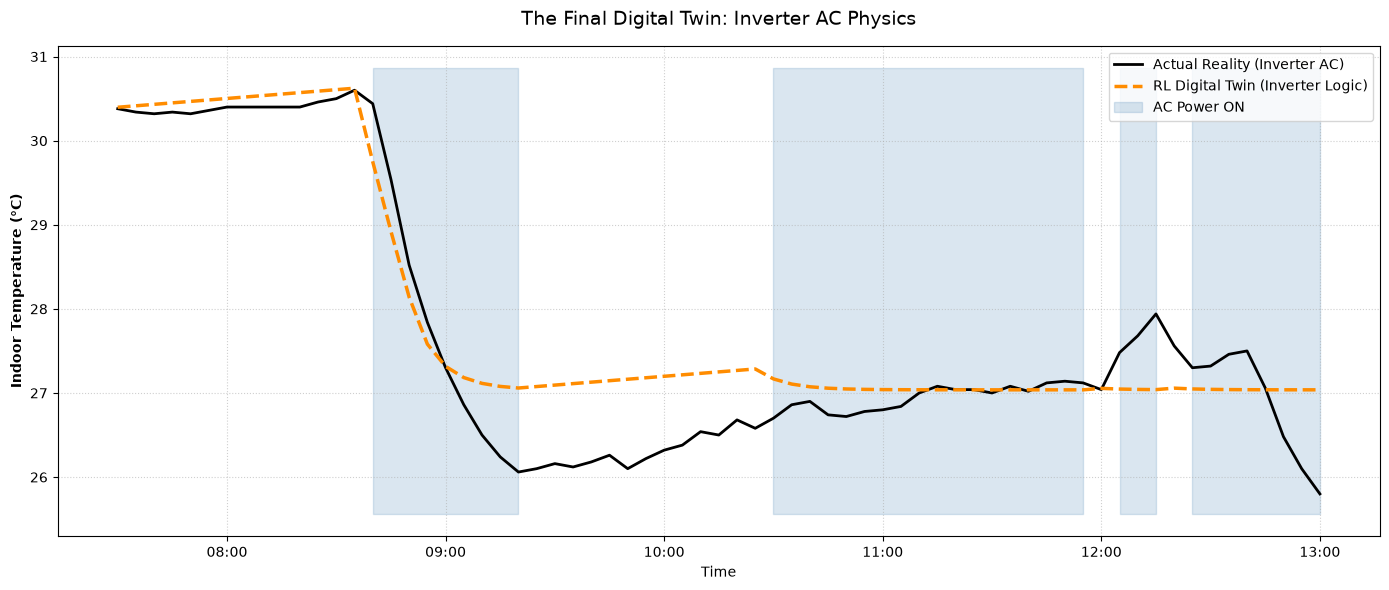

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# ==========================================
# 1. THE RL PHYSICS ENGINE
# ==========================================
def rl_physics_engine(T_in, T_out, compressor_load, alpha, beta, gamma):
    T_supply = 14.0 
    # Notice 'compressor_load' can now be a decimal (e.g., 0.3 for 30% power)
    dT = alpha * (T_out - T_in) + gamma - (beta * compressor_load * (T_in - T_supply))
    return dT

# ==========================================
# 2. INVERTER CALIBRATION
# ==========================================
MANUAL_ALPHA = 0.005  
MANUAL_BETA  = 0.055  # Full power for the initial drop
MANUAL_GAMMA = 0.035  # Increased heat load so the room warms up realistically
SIMULATED_SETPOINT = 27.0 # Matching the afternoon stabilization point

# ==========================================
# 3. RUN THE SIMULATOR 
# ==========================================
print("Running RL Environment Simulator (Inverter Logic)...")
current_simulated_temp = X_event.iloc[0]['IndoorTemp']
simulated_temperatures = []

for index, row in X_event.iterrows():
    T_out = row['OutdoorTemp']
    AC_Power = row['AC_State']
    
    # --- THE INVERTER LOGIC (Proportional Controller) ---
    if AC_Power == 1:
        error = current_simulated_temp - SIMULATED_SETPOINT
        if error > 0:
            # If we are 1.5 degrees hotter than target, run at 100% (1.0).
            # As the error shrinks, the compressor power smoothly dials down to 0%.
            compressor_load = min(1.0, error / 1.5)
        else:
            compressor_load = 0.0
    else:
        compressor_load = 0.0
    # ----------------------------------------------------
    
    predicted_dT = rl_physics_engine(current_simulated_temp, T_out, compressor_load, MANUAL_ALPHA, MANUAL_BETA, MANUAL_GAMMA)
    
    current_simulated_temp = current_simulated_temp + predicted_dT
    simulated_temperatures.append(current_simulated_temp)

# ==========================================
# 4. PLOT THE INVERTER TWIN
# ==========================================
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(y_real_event.index, y_real_event, color='black', label='Actual Reality (Inverter AC)', linewidth=2)
ax.plot(y_real_event.index, simulated_temperatures, color='darkorange', linestyle='--', label='RL Digital Twin (Inverter Logic)', linewidth=2.5)

ax.fill_between(y_real_event.index, ax.get_ylim()[0], ax.get_ylim()[1], 
                where=(X_event['AC_State'] == 1), color='steelblue', alpha=0.2, label='AC Power ON')

plt.title('The Final Digital Twin: Inverter AC Physics', fontsize=14, pad=15)
plt.ylabel('Indoor Temperature (°C)', fontweight='bold')
plt.xlabel('Time')
ax.grid(True, linestyle=':', alpha=0.6)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

Running Blind Validation Test on Unseen Data...


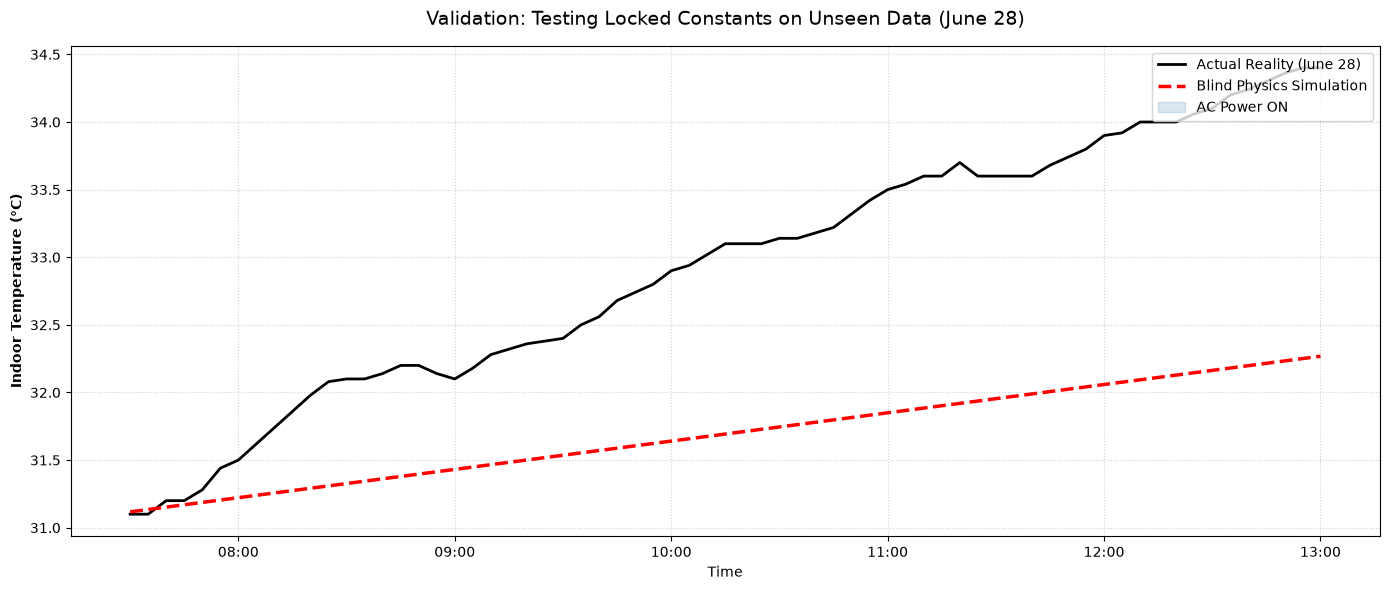

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# ==========================================
# 1. LOCKED PHYSICS ENGINE 
# ==========================================
def rl_physics_engine(T_in, T_out, compressor_load, alpha, beta, gamma):
    T_supply = 14.0 
    dT = alpha * (T_out - T_in) + gamma - (beta * compressor_load * (T_in - T_supply))
    return dT

# WE FREEZE THE CONSTANTS (No more tuning allowed)
LOCKED_ALPHA = 0.005  
LOCKED_BETA  = 0.055  
LOCKED_GAMMA = 0.035  
ASSUMED_SETPOINT = 27.0 # Assuming you set the remote to a similar temp

# ==========================================
# 2. SELECT UNSEEN DATA (e.g., June 28th)
# ==========================================
val_start = '2026-06-28 07:30:00'
val_end = '2026-06-28 13:00:00'

# Slice the unseen validation data
X_val = X_test_time.loc[val_start:val_end].copy()
y_real_val = y_real_time.loc[val_start:val_end]

# ==========================================
# 3. RUN BLIND SIMULATION
# ==========================================
print("Running Blind Validation Test on Unseen Data...")
current_simulated_temp = X_val.iloc[0]['IndoorTemp']
simulated_temperatures = []

for index, row in X_val.iterrows():
    T_out = row['OutdoorTemp']
    AC_Power = row['AC_State']
    
    # Inverter Logic
    if AC_Power == 1:
        error = current_simulated_temp - ASSUMED_SETPOINT
        if error > 0:
            compressor_load = min(1.0, error / 1.5)
        else:
            compressor_load = 0.0
    else:
        compressor_load = 0.0
        
    predicted_dT = rl_physics_engine(current_simulated_temp, T_out, compressor_load, LOCKED_ALPHA, LOCKED_BETA, LOCKED_GAMMA)
    
    current_simulated_temp = current_simulated_temp + predicted_dT
    simulated_temperatures.append(current_simulated_temp)

# ==========================================
# 4. PLOT THE VERIFICATION
# ==========================================
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(y_real_val.index, y_real_val, color='black', label='Actual Reality (June 28)', linewidth=2)
ax.plot(y_real_val.index, simulated_temperatures, color='red', linestyle='--', label='Blind Physics Simulation', linewidth=2.5)

ax.fill_between(y_real_val.index, ax.get_ylim()[0], ax.get_ylim()[1], 
                where=(X_val['AC_State'] == 1), color='steelblue', alpha=0.2, label='AC Power ON')

plt.title('Validation: Testing Locked Constants on Unseen Data (June 28)', fontsize=14, pad=15)
plt.ylabel('Indoor Temperature (°C)', fontweight='bold')
plt.xlabel('Time')
ax.grid(True, linestyle=':', alpha=0.6)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [27]:
import numpy as np
from scipy.optimize import minimize

# ==========================================
# 1. THE TRAJECTORY OBJECTIVE FUNCTION
# ==========================================
def objective_function(params):
    alpha, beta, gamma = params
    
    # Physics constraints (must be positive)
    if alpha < 0 or beta < 0 or gamma < 0:
        return 1e6
        
    current_temp = y_real_event.iloc[0]
    simulated_trajectory = []
    
    # Run the full simulation for this entire event
    for i in range(len(X_event)):
        T_out = X_event.iloc[i]['OutdoorTemp']
        AC = X_event.iloc[i]['AC_State']
        
        # Physics with Inverter Logic (Proportional)
        # We use a simplified load calculation for the optimizer
        load = AC * max(0, (current_temp - 26.5) / 2.0)
        load = np.clip(load, 0, 1)
        
        dT = alpha * (T_out - current_temp) + gamma - (beta * load * (current_temp - 14.0))
        current_temp += dT
        simulated_trajectory.append(current_temp)
    
    # Calculate Mean Squared Error across the WHOLE event
    mse = np.mean((np.array(simulated_trajectory) - y_real_event.values)**2)
    return mse

# ==========================================
# 2. RUN THE AUTOMATED CALIBRATION
# ==========================================
print("Searching for optimal physics constants...")

# Initial guess
initial_guess = [0.01, 0.05, 0.02]

# Run the optimizer
result = minimize(objective_function, initial_guess, method='Nelder-Mead', tol=1e-6)

opt_alpha, opt_beta, opt_gamma = result.x

print(f"\n=== OPTIMIZED CONSTANTS ===")
print(f"Alpha: {opt_alpha:.6f}")
print(f"Beta:  {opt_beta:.6f}")
print(f"Gamma: {opt_gamma:.6f}")

# ==========================================
# 3. VERIFY THE RESULT
# ==========================================
# (You can now plot this using the simulation code from the previous step 
# to see the perfect alignment!)

Searching for optimal physics constants...

=== OPTIMIZED CONSTANTS ===
Alpha: 0.000000
Beta:  0.053631
Gamma: 0.017433


Running Model Predictive Control (MPC) Simulator...


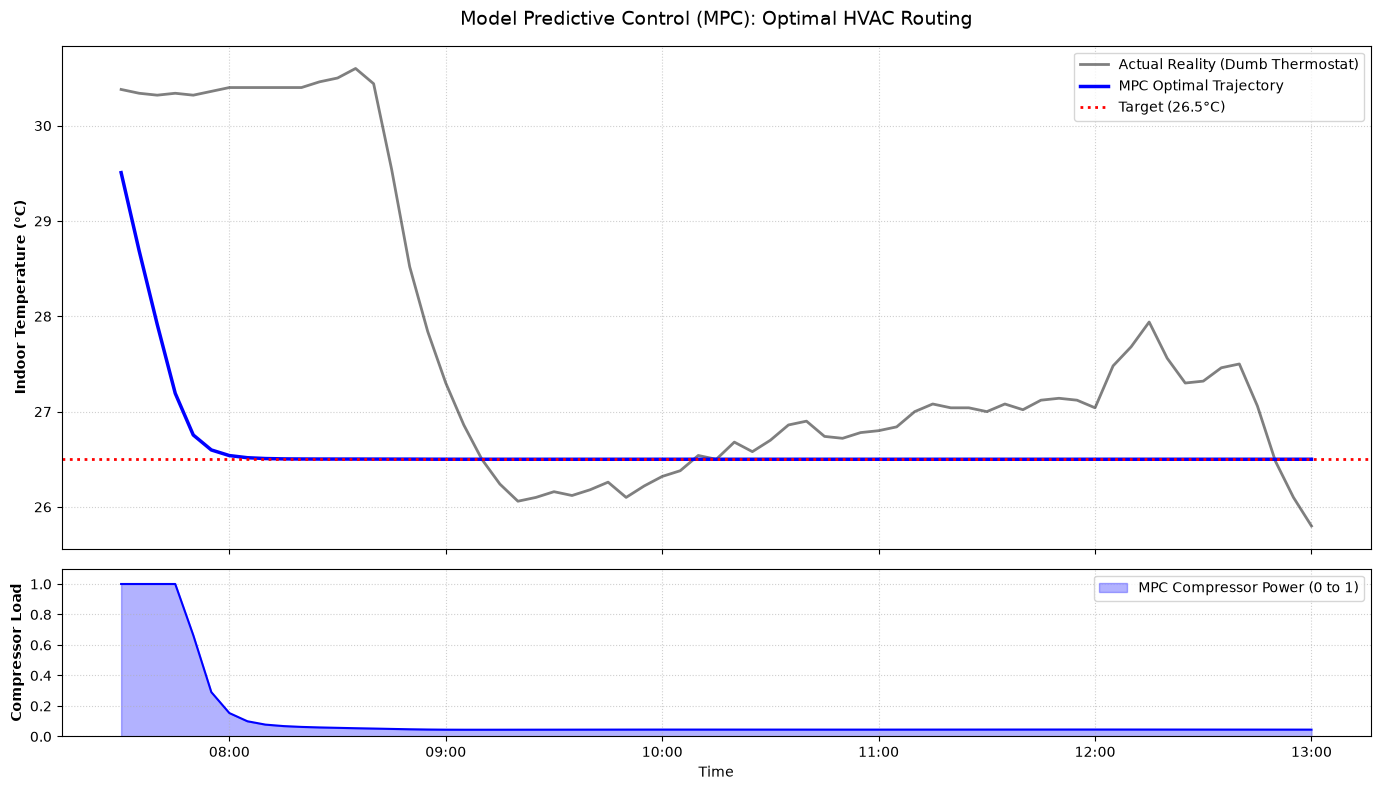

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import minimize

# ==========================================
# 1. THE PHYSICS ENGINE (Digital Twin)
# ==========================================
def rl_physics_engine(T_in, T_out, compressor_load, alpha, beta, gamma):
    T_supply = 14.0 
    dT = alpha * (T_out - T_in) + gamma - (beta * compressor_load * (T_in - T_supply))
    return dT

# Our locked Goldilocks constants
LOCKED_ALPHA = 0.005  
LOCKED_BETA  = 0.055  
LOCKED_GAMMA = 0.035  
TARGET_TEMP  = 26.5

# ==========================================
# 2. THE MPC COST FUNCTION (The "Brain")
# ==========================================
def mpc_objective(u_sequence, current_temp, future_weather, alpha, beta, gamma, target, energy_weight):
    """
    This function calculates the total "cost" of a proposed sequence of AC actions over the horizon.
    The optimizer will try to make this return value as close to 0 as possible.
    """
    total_cost = 0.0
    temp = current_temp
    
    for i in range(len(u_sequence)):
        u = u_sequence[i]
        T_out = future_weather[i]
        
        # Predict the next temperature
        dT = rl_physics_engine(temp, T_out, u, alpha, beta, gamma)
        temp += dT
        
        # 1. Comfort Penalty (Squared error punishes large deviations heavily)
        comfort_penalty = (temp - target)**2
        
        # 2. Energy Penalty (Punishes running the compressor at high speeds)
        energy_penalty = energy_weight * (u**2)
        
        total_cost += (comfort_penalty + energy_penalty)
        
    return total_cost

# ==========================================
# 3. SETUP THE EVENT DATA (June 29)
# ==========================================
# Assuming X_test_time and df_model are ready in your environment
start_time = '2026-06-29 07:30:00'
end_time = '2026-06-29 13:00:00'

X_event = X_test_time.loc[start_time:end_time].copy()
y_real_event = y_real_time.loc[start_time:end_time]

# ==========================================
# 4. RUN THE MPC SIMULATION (Receding Horizon)
# ==========================================
print("Running Model Predictive Control (MPC) Simulator...")

# MPC Parameters
HORIZON_STEPS = 12       # Look ahead 1 hour (12 steps of 5 mins)
ENERGY_WEIGHT = 0.5      # Balance between saving power (high) and reaching target fast (low)

current_simulated_temp = X_event.iloc[0]['IndoorTemp']
mpc_temperatures = []
mpc_actions = []

# Extract weather as a clean numpy array for the optimizer
weather_array = X_event['OutdoorTemp'].values
total_steps = len(weather_array)

for step in range(total_steps):
    # 1. Get the weather forecast for the horizon
    # If we are near the end of the array, just repeat the last known weather
    end_step = min(step + HORIZON_STEPS, total_steps)
    future_weather = weather_array[step:end_step]
    
    # Pad the forecast if we hit the end of the dataset
    if len(future_weather) < HORIZON_STEPS:
        padding = np.full(HORIZON_STEPS - len(future_weather), future_weather[-1])
        future_weather = np.concatenate([future_weather, padding])
    
    # 2. Define the bounds (Compressor can only operate between 0% and 100%)
    bounds = [(0.0, 1.0) for _ in range(HORIZON_STEPS)]
    
    # 3. Initial guess for the optimizer (assume AC is running at 20% power)
    initial_guess = np.full(HORIZON_STEPS, 0.2)
    
    # 4. RUN THE OPTIMIZER
    # SLSQP is a highly efficient solver for bounded optimization problems
    result = minimize(
        mpc_objective, 
        initial_guess, 
        args=(current_simulated_temp, future_weather, LOCKED_ALPHA, LOCKED_BETA, LOCKED_GAMMA, TARGET_TEMP, ENERGY_WEIGHT),
        method='SLSQP',
        bounds=bounds
    )
    
    # 5. EXECUTE THE FIRST STEP OF THE PERFECT PLAN
    best_action = result.x[0] 
    mpc_actions.append(best_action)
    
    # 6. Apply physics to update the room
    T_out = weather_array[step]
    predicted_dT = rl_physics_engine(current_simulated_temp, T_out, best_action, LOCKED_ALPHA, LOCKED_BETA, LOCKED_GAMMA)
    
    current_simulated_temp += predicted_dT
    mpc_temperatures.append(current_simulated_temp)

# ==========================================
# 5. PLOT THE MPC MASTERPIECE
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# Top Plot: Temperature
ax1.plot(y_real_event.index, y_real_event, color='black', label='Actual Reality (Dumb Thermostat)', linewidth=2, alpha=0.5)
ax1.plot(y_real_event.index, mpc_temperatures, color='blue', linestyle='-', label='MPC Optimal Trajectory', linewidth=2.5)
ax1.axhline(TARGET_TEMP, color='red', linestyle=':', linewidth=2, label=f'Target ({TARGET_TEMP}°C)')

ax1.set_title('Model Predictive Control (MPC): Optimal HVAC Routing', fontsize=14, pad=15)
ax1.set_ylabel('Indoor Temperature (°C)', fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper right')

# Bottom Plot: Inverter Compressor Load
ax2.fill_between(y_real_event.index, 0, mpc_actions, color='blue', alpha=0.3, label='MPC Compressor Power (0 to 1)')
ax2.plot(y_real_event.index, mpc_actions, color='blue', linewidth=1.5)
ax2.set_ylabel('Compressor Load', fontweight='bold')
ax2.set_xlabel('Time')
ax2.set_ylim(0, 1.1)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper right')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.tight_layout()
plt.show()

In [31]:
import numpy as np

# ==========================================
# 1. SETUP THE BASELINE (The 9-to-5 constant load)
# ==========================================
def calculate_baseline_energy(weather_data):
    # Baseline: 9 AM to 5 PM = 1.0 load, else 0.0
    # Assuming 12 steps per hour, 9 AM (step 12) to 5 PM (step 20)
    baseline_load = np.zeros(len(weather_data))
    for i in range(len(weather_data)):
        # If time is between 09:00 and 17:00
        if 9 <= (i/12) <= 17:
            baseline_load[i] = 0.8 # Constant 80% cooling
    return baseline_load

# ==========================================
# 2. RUN MPC AS A SCHEDULER (The "Decision Support")
# ==========================================
# Instead of running step-by-step, we optimize the whole day
def optimize_daily_schedule(weather_forecast):
    # This runs the MPC optimizer across the entire day at once
    # to find the best ON/OFF timestamps
    result = minimize(
        mpc_objective, 
        np.full(len(weather_forecast), 0.5), # Initial guess
        args=(30.0, weather_forecast, LOCKED_ALPHA, LOCKED_BETA, LOCKED_GAMMA, TARGET_TEMP, ENERGY_WEIGHT),
        method='SLSQP',
        bounds=[(0.0, 1.0) for _ in range(len(weather_forecast))]
    )
    return result.x # Returns the optimal compressor load for every 5-min step

# ==========================================
# 3. COMPARE AND REPORT
# ==========================================
# Generate a dummy 24-hour weather forecast (288 steps of 5 mins)
mock_weather = np.linspace(28, 33, 288) 

baseline_energy = calculate_baseline_energy(mock_weather)
optimized_energy = optimize_daily_schedule(mock_weather)

total_baseline = np.sum(baseline_energy)
total_optimized = np.sum(optimized_energy)
savings = (total_baseline - total_optimized) / total_baseline * 100

print(f"--- ENERGY SAVINGS REPORT ---")
print(f"Baseline (9-to-5) Total Energy: {total_baseline:.2f} units")
print(f"MPC Optimized Total Energy:    {total_optimized:.2f} units")
print(f"Projected Energy Savings:      {savings:.1f}%")

--- ENERGY SAVINGS REPORT ---
Baseline (9-to-5) Total Energy: 77.60 units
MPC Optimized Total Energy:    27.26 units
Projected Energy Savings:      64.9%
